In [115]:
import random
import json
import os, sys
from importlib import reload
from pathlib import Path
import numpy as np
import pandas as pd

import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer

random.seed(6)
np.random.seed(6)

hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")


In [116]:
# My modules

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    video_tools)

from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as videoviz


In [117]:
# Files
STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

#VQA_RESP = WORK_DIR / "outputs/vqa_video_fps_gemma3:4b-it-qat_20250629_16:44:00.jsonl"

#SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_gemini25flash_1000.jsonl"

#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250805_15:48:00.jsonl"
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250806_17:30:00.jsonl"
#GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250805_15:48:00.jsonl"

# on the 200 sub-set
SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_200.jsonl"
GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_on_geminiSGG_gemini2.5flash_20250804_21:49:00.jsonl"
GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_200_20250804_19:21:00.jsonl"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")



prev_analyzed = [
    "Interaction_T1_4054",
    "Interaction_T1_8913",
    "Interaction_T2_3423",
    "Interaction_T1_4115",
    "Interaction_T1_1168",
    "Interaction_T1_309",
    "Interaction_T1_4703",
    "Interaction_T1_2516",
    "Interaction_T1_8967",
    "Interaction_T1_5709",
    "Interaction_T1_2226",
    "Interaction_T1_111",
    "Interaction_T1_8274",
    "Interaction_T1_7254",
    "Interaction_T1_4221",
    #"Interaction_T1_3485",
    #"Interaction_T4_4181",
    #"Interaction_T2_1847",
]

SHOW_VIDEO = False


# Experiment

# Prompts

## VQA

In [118]:
with open(WORK_DIR / 'data/prompts/vqa/user_prompt.txt', 'r') as f:
    pr = f.read()

print(pr)


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by

In [119]:
with open(WORK_DIR / 'data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt', 'r') as f:
    pr = f.read()

print(pr)


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



## SGG

In [120]:
with open(WORK_DIR / "data/prompts/graph-gen/user_prompt_v2.txt") as f:
    pr = f.read()
    
print(pr)
    


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by the person;
7.

In [121]:
with open(WORK_DIR / "data/prompts/graph-gen/format_instructions_v2corrected.txt") as f:
    pr = f.read()
    
print(pr)
    


Now organize the objects and relationships you identified before into a formal spatio-temporal scene graph using this format for the predicates: 
object1 ---- relationship ---- object2

The spatio-temporal scene graph should be enclosed between the tags <stsg> and </stsg>.
The list of relationship predicates pertaining a frame should be introduced by the frame ID or name and enclosed in the tags <scene_graph> and </scene_graph>:


For example:
<stsg>
Frame 0:
<scene_graph>
man ----  sitting_on ---- chair
dog ---- lying_under ----  table
book ---- on_top_of ---- shelf
woman ---- on_the_right_of ---- man
... 
</scene_graph>

Frame 1:
<scene_graph>
woman ---- on_the_left_of ---- man
...
</scene_graph>
</stsg>


Please follow these guidelines:
1. Create an appropriate number of relationship triplets (more if the image is complex)
2. Use specific and consistent object labels
3. Use concise but descriptive relationship terms (connect words with underscores)
4. Include all meaningful relation

### Graph understanding from the SGG

In [122]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/MCQ_system_prompt_ZS_CoT.txt") as f:
    pr = f.read()
    
print(pr)
    


You need to respond to reasoning questions by making logical inference on sequence of Scene-Graphs extracted from frames belonging to a video, called a Spatio-Temporal Scene Graph.

IMPORTANT CLARIFICATIONS:
- You will receive a question and Spatio-Temporal Scene-Graph
- Each Scene-Graph is a static symbolic representation of the scene unfolding in the frame
- The Scene-Graphs are ordered chronologically
- The Scene-Graph is represented as a set of tuple in the format: subject - relationship - object
- The Spatio-Temporal Scene-Graph is a cornologically sorted list of Scene-Graphs

INSTRUCTIONS:
- Read the entire Spatio-Temporal Scene-Graphs in chronological order and pay attention at the order of how events unfold.
- Read the question and reason about the answer step by step.
- In your answer include key events or relationships that help you in determing the correct answer.
- Be careful to reproduce the chosen alternative as it is presented.


In [123]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/MCQ_user_prompt_ZS_CoT_v3.txt") as f:
    pr = f.read()
    
print(pr)
    


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
{stsg}
</STSG>

Given the following question:
<Q>
{question}
<Q>

And the following alternatives:
<Alternatives>
A. {c1}
B. {c2}
C. {c3}
D. {c4}
</Alternatives>

Provide an answer to the above question reasoning step by step on the Spatio-Temporal Scene-Graph (STSG) and choosing one of the alternatives. 

In answering the question please be sure to operate according to the following guidlines:
1. Question Interpretation: Clearly state what the question is asking
2. STSG Analysis: Carefully examine the spatial and temporal relationships in the scene graph
3. Alternative Evaluation: For each option (A, B, C, D), explain whether it matches the STSG evidence
4. Reasoning: Provide clear logical step by step reasoning leading to your conclusion
5. Conclusion: Declare the logical conclusion to your reasoning in the above step
6. Consistency Check: B

In [124]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt") as f:
    pr = f.read()
    
print(pr)
    


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



# Loading GT

Let's load the ground truth from the `STAR_QA_question_and_stsg_val.json` file where we extracted QA and spatio-temporal scene graphs

In [125]:
with open(STAR_VAL_SMALL) as f:
    ground_truth = json.load(f)


gt_df = pd.DataFrame(ground_truth).astype({'question_id': 'string', 'answer': 'string'})
gt_df.rename(columns={"question_id": "id", "answer": "text"}, inplace=True)
gt_df.set_index('id', inplace=True)
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   string 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(5), string(1)
memory usage: 73.7+ KB


# Loading Generated Grpahs

In [126]:
sgg_df = pd.read_json(SGG_GRAPHS, lines=True)
sgg_df


,key,request,response_x,response_y,question_id,stsg
0,Prediction_T1_2102,"{'contents': [{'role': 'user', 'parts': [{'tex...",{'usageMetadata': {'promptTokensDetails': [{'t...,{'usageMetadata': {'promptTokensDetails': [{'m...,Prediction_T1_2102,<stsg>\nFrame 0-1:\n<scene_graph>\nperson_hand...
1,Interaction_T4_3931,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'responseId': 'TNiLaJLYGfDtjrEPhemfwAo', 'usa...","{'modelVersion': 'gemini-2.5-flash', 'usageMet...",Interaction_T4_3931,<stsg>\nFrame 0:\n<scene_graph>\nperson ---- s...
2,Interaction_T1_9123,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'candidates': [{'index': 0, 'content': {'role...",{'usageMetadata': {'promptTokensDetails': [{'m...,Interaction_T1_9123,<stsg>\nFrame 0:\n<scene_graph>\noverhead_ligh...
3,Prediction_T1_2737,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'usageMetadata': {'promptTokenCount': 3954, '...","{'responseId': 'RduLaOXdO6jtjrEPmNCSyQo', 'usa...",Prediction_T1_2737,<stsg>\nFrame 0:\n<scene_graph>\nman ---- wear...
4,Prediction_T3_495,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'candidates': [{'finishReason': 'STOP', 'cont...","{'modelVersion': 'gemini-2.5-flash', 'candidat...",Prediction_T3_495,<stsg>\nFrame 0:\n<scene_graph>\nwoman ---- st...
...,...,...,...,...,...,...
194,Interaction_T1_2516,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'modelVersion': 'gemini-2.5-flash', 'usageMet...","{'modelVersion': 'gemini-2.5-flash', 'usageMet...",Interaction_T1_2516,<stsg>\nFrame 0:\n<scene_graph>\nperson ---- s...
195,Sequence_T6_2698,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'candidates': [{'content': {'role': 'model', ...","{'modelVersion': 'gemini-2.5-flash', 'usageMet...",Sequence_T6_2698,<stsg>\nFrame 0:\n<scene_graph>\nman ---- stan...
196,Feasibility_T2_363,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'candidates': [{'content': {'role': 'model', ...","{'modelVersion': 'gemini-2.5-flash', 'usageMet...",Feasibility_T2_363,<stsg>\nFrame 0:\n<scene_graph>\nman ---- near...
197,Feasibility_T5_907,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'modelVersion': 'gemini-2.5-flash', 'candidat...","{'responseId': 'veKLaNTrB5nI-8YP9tXTkAU', 'can...",Feasibility_T5_907,<stsg>\nFrame 0:\n<scene_graph>\nman ---- stan...


In [127]:
print(sgg_df.iloc[0]['request']['contents'][3]['parts'][0]['text'])


<stsg>
Frame 0-1:
<scene_graph>
person_hand ---- obscures ---- person_face
person ---- in_front_of ---- refrigerator
person ---- near ---- wooden_cabinets
wooden_cabinets ---- to_the_left_of ---- refrigerator
</scene_graph>

Frame 2-3:
<scene_graph>
person_arm ---- moves_across ---- frame
person ---- near ---- refrigerator
person ---- near ---- wooden_cabinets
refrigerator ---- to_the_left_of ---- countertop
countertop ---- contains ---- various_items
</scene_graph>

Frame 4:
<scene_graph>
person ---- walks_towards ---- refrigerator
person_arm ---- extended_towards ---- refrigerator
refrigerator ---- to_the_left_of ---- person
person ---- in_front_of ---- kitchen_environment
</scene_graph>

Frame 5:
<scene_graph>
person ---- opens ---- refrigerator_door
person ---- holds ---- glass
person_hand ---- reaches_into ---- refrigerator
refrigerator_door ---- open ---- refrigerator
refrigerator ---- contains ---- food_items
</scene_graph>

Frame 6-8:
<scene_graph>
person ---- bends_down_at ---

In [128]:
print(sgg_df.iloc[0]['stsg'])


<stsg>
Frame 0-1:
<scene_graph>
person_hand ---- obscures ---- person_face
person ---- in_front_of ---- refrigerator
person ---- near ---- wooden_cabinets
wooden_cabinets ---- to_the_left_of ---- refrigerator
</scene_graph>

Frame 2-3:
<scene_graph>
person_arm ---- moves_across ---- frame
person ---- near ---- refrigerator
person ---- near ---- wooden_cabinets
refrigerator ---- to_the_left_of ---- countertop
countertop ---- contains ---- various_items
</scene_graph>

Frame 4:
<scene_graph>
person ---- walks_towards ---- refrigerator
person_arm ---- extended_towards ---- refrigerator
refrigerator ---- to_the_left_of ---- person
person ---- in_front_of ---- kitchen_environment
</scene_graph>

Frame 5:
<scene_graph>
person ---- opens ---- refrigerator_door
person ---- holds ---- glass
person_hand ---- reaches_into ---- refrigerator
refrigerator_door ---- open ---- refrigerator
refrigerator ---- contains ---- food_items
</scene_graph>

Frame 6-8:
<scene_graph>
person ---- bends_down_at ---

# Loading predicted answers evaluation

In [129]:
gemma_pred_gg_df = rp.ans_extract(GEMMA_RESPONSES_FPATH, "gemma3", format="ollama")
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_FPATH, "gemma3", format="gemini")


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {  "answer": "Based on the provided Spatio-Temporal Scene Graph, the person does not close any object before holding a 'small_dark_object' (Frame 4) or a 'mobile_phone' (Frame 5). The 'upper_cabinet' door, which the person interacts with, is explicitly stated to be 'open' from Frame 3 until the end of the sequence (Frame 8). Therefore, none of the alternatives are supported by the given STSG as an action that occurred. Since I must choose one of the alternatives, and acknowledging the lack of evidence for any closing action, it is impossible to definitively select a correct answer from the given options based on the provided STSG. If forced to choose the "closest" related object, it would be the cabinet/door, but the ac

Total answers: 199
Answers following JSON template: 199
Percentage following JSON template: 100.00%
Answer with a valid alternative: 196
98.49% of the total

Invalid answers: 3
Total answers: 199
Answers following JSON template: 199
Percentage following JSON template: 100.00%
Answer with a valid alternative: 150
75.38% of the total

Invalid answers: 49


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


### Gemini sanity-check

#### Sample question

In [130]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][0]["content"])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0-1:
<scene_graph>
person_hand ---- obscures ---- person_face
person ---- in_front_of ---- refrigerator
person ---- near ---- wooden_cabinets
wooden_cabinets ---- to_the_left_of ---- refrigerator
</scene_graph>

Frame 2-3:
<scene_graph>
person_arm ---- moves_across ---- frame
person ---- near ---- refrigerator
person ---- near ---- wooden_cabinets
refrigerator ---- to_the_left_of ---- countertop
countertop ---- contains ---- various_items
</scene_graph>

Frame 4:
<scene_graph>
person ---- walks_towards ---- refrigerator
person_arm ---- extended_towards ---- refrigerator
refrigerator ---- to_the_left_of ---- person
person ---- in_front_of ---- kitchen_environment
</scene_graph>

Frame 5:
<scene_graph>
person ---- opens ---- refrigerator_door
person ---- holds ---- glass
person_hand ---- reaches_into ---- refrigerator
refrigerator

In [131]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][1]["content"])



1. **Question Interpretation:** The question asks to predict the next action the person will take based on the provided Spatio-Temporal Scene Graph.

2. **STSG Analysis:**

   *   **Frame 0-1:** The person is near a refrigerator and wooden cabinets.
   *   **Frame 2-3:** The person is still near the refrigerator and cabinets.
   *   **Frame 4:** The person walks towards the refrigerator with an extended arm.
   *   **Frame 5:** The person opens the refrigerator door and reaches inside, holding a glass.
   *   **Frame 6-8:** The person is bent down at the refrigerator, hand inside, holding a glass, and looking at the contents.
   *   **Frame 9-17:** The person holds a bottle and a glass, pours liquid into the glass from the bottle, and the refrigerator door is still open.
   *   **Frame 18-21:** The person is in the act of "closes ---- refrigerator_door" and "refrigerator_door ---- closing ---- refrigerator", while holding the glass with liquid.

3. **Alternative Evaluation:**

    *  

In [132]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][2]["content"])



Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



In [133]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][3]["content"])



```json
{"answer": "B. Close the refrigerator."}
```


#### Unanswered questions

In [134]:
for _, row in gemini_pred_gg_df[~gemini_pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])



{"answer": "Based on the provided Spatio-Temporal Scene Graph, the woman is shown holding a plate containing food (Frame 0-9) and then eating that food (Frame 2-5). There is no information in the STSG to suggest that the woman ate any object *before* she held the food. Additionally, none of the specific alternatives (A. The closet/cabinet, B. The sandwich, C. The medicine, D. The laptop) are mentioned as being present or eaten in the STSG. Therefore, the question cannot be answered from the provided STSG and alternatives, as the premise of eating something before holding the food is not supported, and the specific alternatives are not present in the scene graph."}

```json
{
"answer": "None of the provided alternatives (A. The clothes, B. The shoe, C. The dish, D. The pillow) are explicitly mentioned in the Spatio-Temporal Scene Graph as objects the man is able to hold after opening the door. The STSG states that the wooden door reveals a 'pantry' which 'contains ---- food_items'. The

### Gemma sanity check

#### Sample question

In [135]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][0]["content"])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- holding ---- book
person ---- looking_towards ---- right_of_frame
window ---- to_the_left_of ---- person
window ---- to_the_left_of ---- light_switch
light_switch ---- on ---- wall
decorative_screen ---- behind ---- light_switch
</scene_graph>

Frame 1:
<scene_graph>
person ---- holding ---- book
person ---- reaching_towards ---- light_switch
person ---- looking_at ---- light_switch
light_switch ---- on ---- wall
window ---- to_the_left_of ---- person
decorative_screen ---- behind ---- light_switch
</scene_graph>

Frame 2:
<scene_graph>
person ---- holding ---- book
person ---- touching ---- light_switch
light_switch ---- illuminated ---- true
light_switch ---- on ---- wall
window ---- to_the_left_of ---- person
decorative_screen ---- behind ---- light_switch
</scene_graph>

Frame 3:
<scene_graph>
per

In [136]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][1]["content"])


Okay, let's analyze the scene graph and answer the question step-by-step.

1. **Question Interpretation:** The question asks what actions the person is able to perform *with* the window, based on the provided scene graph.

2. **STSG Analysis:** The scene graph describes the person's actions and relationships with various objects, including the window. We see the window consistently positioned “to the left of” the person throughout all frames. There are no actions explicitly stated about the person interacting with the window – no opening, closing, touching, or looking *at* it in a way that suggests interaction. The window is simply a static element in the scene.

3. **Alternative Evaluation:**
   * **A. Lie on the window.** – The scene graph doesn’t provide any evidence that the person is lying down or interacting with the window in a way that would allow them to lie on it.
   * **B. Hold the window.** – The scene graph shows the person holding a book, not the window.
   * **C. Close t

In [137]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][2]["content"])


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\


In [138]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][3]["content"])


```json
{"answer": "D. Open the window."}
```


#### Unanswered questions

In [139]:
for _, row in gemma_pred_gg_df[~gemma_pred_gg_df['contains_answer']].iterrows():
    print(row["chat_history"][-1]["content"])


```json
{"answer": "None of the provided alternatives accurately describe the events leading up to the woman’s interaction with the tablet. The scene graph indicates she initially interacted with the light-colored object on her lap before engaging with the tablet."}
```
```json
{"answer": "No answer is possible based on the provided scene graph."}
```
```json
{"answer": "None of the above"}
```


# Evals

## Gemma

In [140]:
gemma_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemma_eval_df = gt_df.join(
    gemma_pred_gg_df[gemma_pred_gg_df['contains_answer']], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(gemma_eval_df, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          50         50.00%  
Sequence             49         67.35%  
Prediction           49         53.06%  
Feasibility          48         35.42%  

Average              196        51.53%  


/home/lusha/star_code/src/response_processing.py:410: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


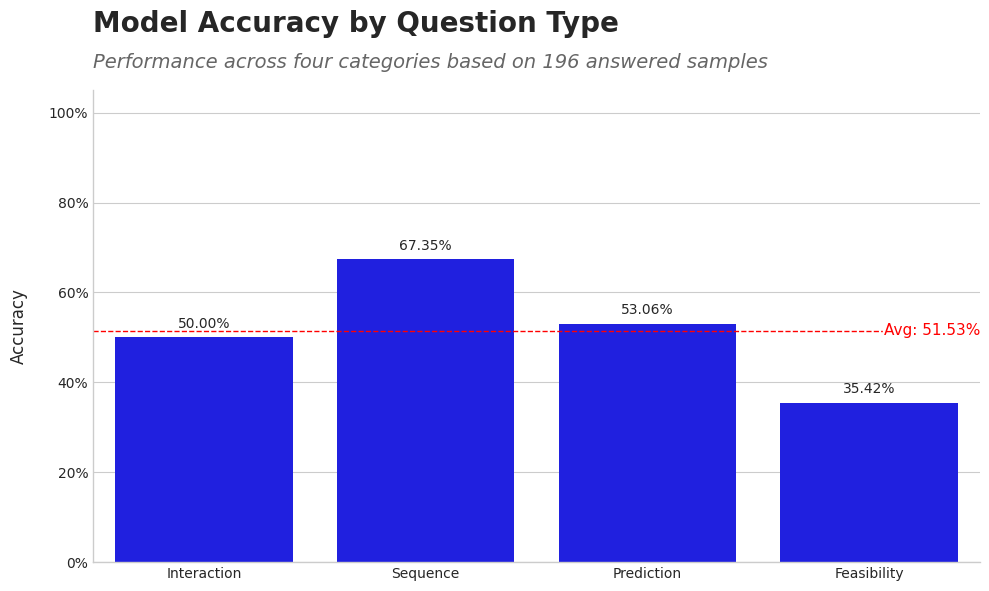

In [ ]:
rp.plot_acc(gemma_eval_df, lambda x: rp.accuracy(x, on_what='text'))


In [142]:
rp.print_ans_perc(gemma_eval_df, gemma_pred_gg_df)


Question type       Total      Answered 

Interaction          50        100.00%  
Sequence             50         98.00%  
Prediction           49        100.00%  
Feasibility          50         96.00%  
Overall              199        98.49%  


/home/lusha/star_code/src/response_processing.py:479: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


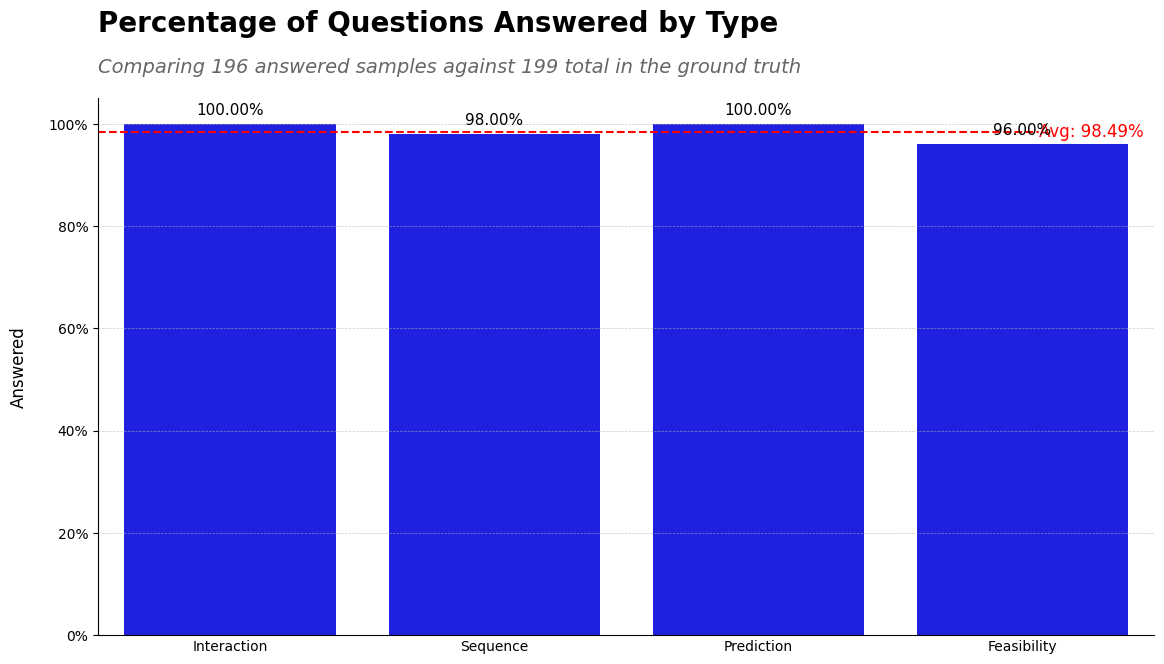

In [143]:
rp.plot_ans_perc(gemma_eval_df, gemma_pred_gg_df)


## Gemini

In [144]:
gemini_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemini_eval_df = gt_df.join(
    gemini_pred_gg_df[gemini_pred_gg_df['contains_answer']], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(gemini_eval_df, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          36         72.22%  
Sequence             37         83.78%  
Prediction           39         64.10%  
Feasibility          38         42.11%  

Average              150        65.33%  


/home/lusha/star_code/src/response_processing.py:410: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


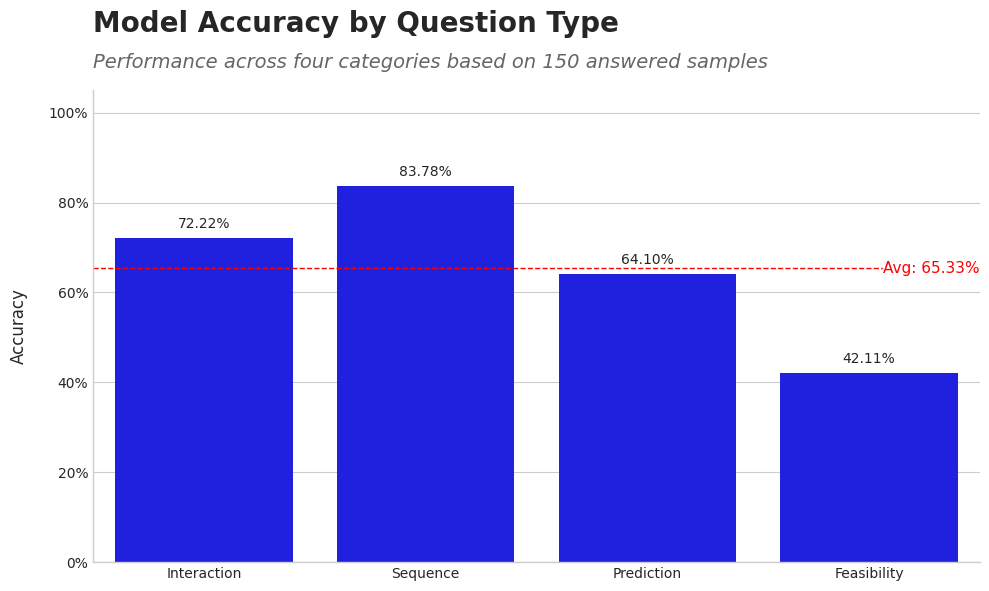

In [ ]:
rp.plot_acc(gemini_eval_df, lambda x: rp.accuracy(x, on_what='text'))


In [146]:
rp.print_ans_perc(gemini_eval_df, gemini_pred_gg_df)


Question type       Total      Answered 

Interaction          50         72.00%  
Sequence             50         74.00%  
Prediction           49         79.59%  
Feasibility          50         76.00%  
Overall              199        75.38%  


/home/lusha/star_code/src/response_processing.py:479: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


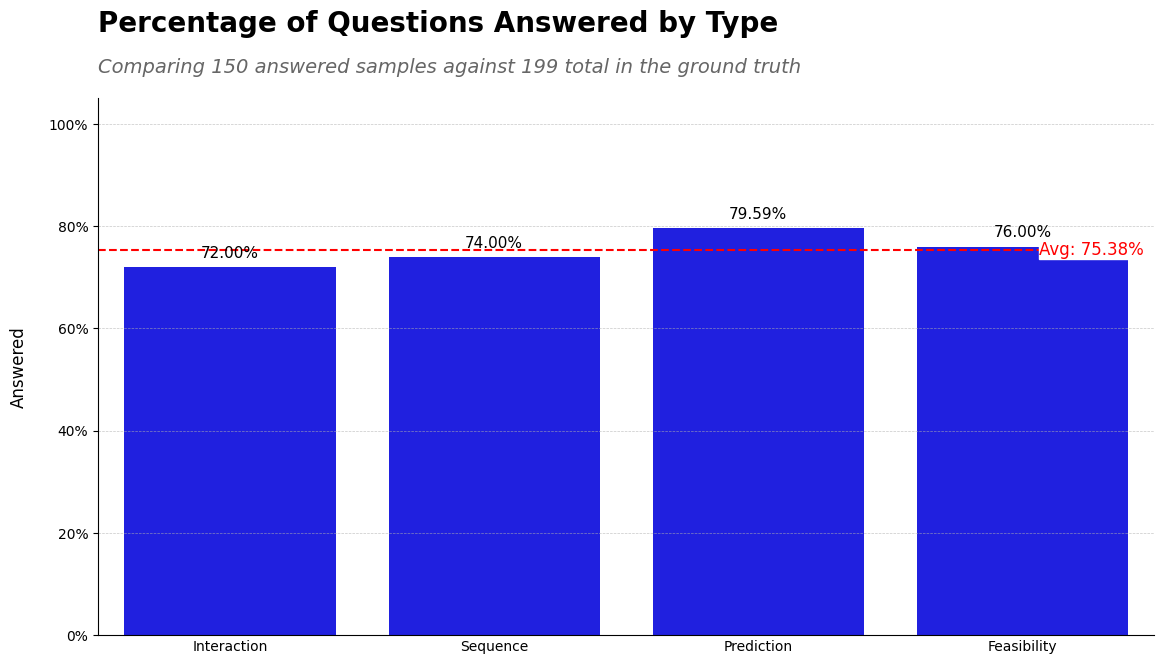

In [147]:
rp.plot_ans_perc(gemini_eval_df, gemini_pred_gg_df)


# Combining

In [148]:
eval_df_all = (
    gt_df
    .join(
        gemma_pred_gg_df[gemma_pred_gg_df['contains_answer']]\
        .rename(columns={'pred_text': 'pred_text1'})[['pred_text1']],
        how='inner'
    ).join(
        gemini_pred_gg_df[gemini_pred_gg_df['contains_answer']]\
        .rename(columns={'pred_text': 'pred_text2'})[['pred_text2']],
        how='inner'
    )
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
id,,,,
Interaction_T1_2354,Which object was put down by the person?,the towel.,the towel.,the towel.
Prediction_T4_1805,Which object would the person close next after...,the closet/cabinet.,the closet/cabinet.,the closet/cabinet.
Feasibility_T5_438,Which object is the person able to put down af...,the clothes.,the clothes.,the clothes.
Interaction_T2_3685,What did the person do with the sofa/couch?,sat on.,sat on.,sat on.
Interaction_T1_4527,Which object was taken by the person?,the blanket.,the blanket.,the blanket.
...,...,...,...,...
Interaction_T1_8913,Which object was taken by the person?,the paper/notebook.,the paper/notebook.,the paper/notebook.
Interaction_T1_8967,Which object was taken by the person?,the dish.,the dish.,the dish.
Interaction_T2_1847,What did the person do with the paper/notebook?,took.,took.,put down.


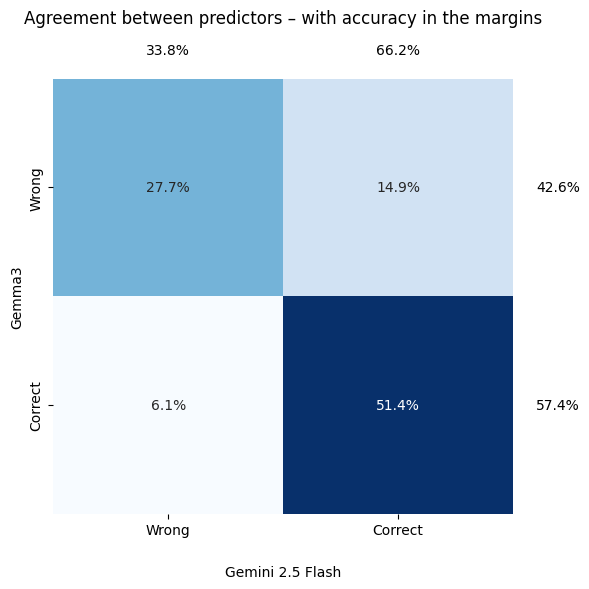

(148, 10)


In [149]:
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gemini 2.5 Flash', labelpad=20)
ax.set_ylabel('Gemma3')
ax.set_title('Agreement between predictors – with accuracy in the margins', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


### Why is the accuracy with the generated SG as base so low?

In [ ]:
answered_questions = [idx for idx in gemini_eval_df.index if idx in prev_analyzed]


In [ ]:
answered_questions


['Interaction_T1_4115',
 'Interaction_T1_4221',
 'Interaction_T1_111',
 'Interaction_T1_309',
 'Interaction_T1_1168',
 'Interaction_T1_2516',
 'Interaction_T1_8274',
 'Interaction_T1_8913',
 'Interaction_T1_8967',
 'Interaction_T2_3423']

### Looking at some of the answers

In [155]:
rp.print_acc(gemini_eval_df.loc[answered_questions], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          10         70.00%  
Sequence              0          nan%   
Prediction            0          nan%   
Feasibility           0          nan%   

Average              10         70.00%  


/home/lusha/star_code/src/response_processing.py:295: RuntimeWarning: invalid value encountered in scalar divide
  return hits_text / eval_df.shape[0]


In 1/3 (= 5 samples) of the manually inspected samples the new fps based model is able to answer correctly. Let's see why...

In [156]:
correct_idx = (gemini_eval_df.loc[answered_questions, 'text'] == gemini_eval_df.loc[answered_questions, 'pred_text'])
correct_idx =  correct_idx[correct_idx].index
correct_idx


Index(['Interaction_T1_4115', 'Interaction_T1_4221', 'Interaction_T1_111',
       'Interaction_T1_2516', 'Interaction_T1_8274', 'Interaction_T1_8913',
       'Interaction_T1_8967'],
      dtype='object', name='id')

#### 0

In [157]:
idx = correct_idx[0]


In [158]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemini_pred_gg_df.rename(columns={'pred_text': 'answer'})])



┌─ Sample: Interaction_T1_4115 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was put down by the person?
│ Alternatives:
│    0. The pillow.
│    1. The box.
│    2. The laptop.
│    3. The sandwich.
│
│ Ground Truth:
│    The laptop.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  The laptop. [CORRECT]
│    Reasoning:
│        
│        1. **Question Interpretation:** The question asks to identify which object the person put down, based on the actions described in the Spatio-Temporal Scene Graph.
│        
│        2. **STSG Analysis:** I will analyze the sequence of events related to the person and objects, specifically looking for actions of putting something down.
│        
│            *   **Frame 0:** "laptop ---- on_lap_of ---- person" - The person has the laptop on their lap.
│            *   **Frame 1:** "laptop ---- on_lap_of ---- person" - The laptop is still on the person's lap.
│            *   **Frame 2:** "person

## Inspection - 1
Check why Gemini doesn't answer some on the questions

In [ ]:
gemma_pred_gg_df = rp.ans_extract(GEMMA_RESPONSES_FPATH, "gemma3", format="ollama")
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_FPATH, "gemma3", format="gemini")


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {  "answer": "Based on the provided Spatio-Temporal Scene Graph, the person does not close any object before holding a 'small_dark_object' (Frame 4) or a 'mobile_phone' (Frame 5). The 'upper_cabinet' door, which the person interacts with, is explicitly stated to be 'open' from Frame 3 until the end of the sequence (Frame 8). Therefore, none of the alternatives are supported by the given STSG as an action that occurred. Since I must choose one of the alternatives, and acknowledging the lack of evidence for any closing action, it is impossible to definitively select a correct answer from the given options based on the provided STSG. If forced to choose the "closest" related object, it would be the cabinet/door, but the ac

Total answers: 1032
Answers following JSON template: 1032
Percentage following JSON template: 100.00%
Answer with a valid alternative: 989
95.83% of the total

Invalid answers: 43
Total answers: 199
Answers following JSON template: 199
Percentage following JSON template: 100.00%
Answer with a valid alternative: 150
75.38% of the total

Invalid answers: 49


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [ ]:
gemini_unanswered = gemini_pred_gg_df[~gemini_pred_gg_df['contains_answer']]
gemini_unanswered_index = gemini_unanswered.index


### Sample

In [ ]:
idx = gemini_unanswered_index[1]
idx


'Feasibility_T5_1670'

In [ ]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemini_pred_gg_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Feasibility_T5_1670 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object is the person able to hold after opening the door?
│ Alternatives:
│    0. The clothes.
│    1. The shoe.
│    2. The dish.
│    3. The pillow.
│
│ Ground Truth:
│    The dish.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:   [WRONG]
│    Reasoning:
│        
│        Here's a step-by-step reasoning to answer the question:
│        
│        1.  **Question Interpretation:** The question asks what object the man is able to hold *after opening the door*. This implies looking for an object that becomes accessible or visible once the door is open.
│        
│        2.  **STSG Analysis:**
│            *   **Frame 0:** Describes the initial scene. A man is in front of a wooden door. The door has a handle. There's a window, washing machine, red box, kitchen counter, dark cabinets, and microwave oven visible, but nothing related to *inside* the wooden door.
│

In [ ]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][0]['content'])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
man ---- stands_in_front_of ---- wooden_door
man ---- wears ---- plaid_shirt
man ---- wears ---- blue_jeans
wooden_door ---- has ---- door_handle
window ---- visible_to_left_of ---- wooden_door
natural_light ---- comes_from ---- window
washing_machine ---- is_below ---- window
red_box ---- is_near ---- washing_machine
red_box ---- labeled ---- ANUB_CREEK
kitchen_counter ---- is_to_right_of ---- wooden_door
dark_cabinets ---- are_part_of ---- kitchen_counter
microwave_oven ---- is_above ---- kitchen_counter
</scene_graph>

Frame 1:
<scene_graph>
man ---- opens ---- wooden_door
man ---- holds_near ---- door_handle
wooden_door ---- reveals ---- pantry
pantry ---- contains ---- food_items
food_items ---- are_on ---- shelves
man ---- faces ---- pantry
</scene_graph>

Frame 2:
<scene_graph>
man ---- stands_inside_open

In [ ]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][1]['content'])



Here's a step-by-step reasoning to answer the question:

1.  **Question Interpretation:** The question asks what object the man is able to hold *after opening the door*. This implies looking for an object that becomes accessible or visible once the door is open.

2.  **STSG Analysis:**
    *   **Frame 0:** Describes the initial scene. A man is in front of a wooden door. The door has a handle. There's a window, washing machine, red box, kitchen counter, dark cabinets, and microwave oven visible, but nothing related to *inside* the wooden door.
    *   **Frame 1:** "man ---- opens ---- wooden_door". Crucially, "wooden_door ---- reveals ---- pantry" and "pantry ---- contains ---- food_items". "food_items ---- are_on ---- shelves". The man then "faces ---- pantry". This frame establishes that opening the door reveals a pantry containing food items.
    *   **Frame 2:** The man "stands_inside_opening_of ---- pantry", "turns_towards ---- pantry_interior", and "looks_down_at ---- lower_shelv

In [ ]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][3]['content'])



```json
{
"answer": "None of the provided alternatives (A. The clothes, B. The shoe, C. The dish, D. The pillow) are explicitly mentioned in the Spatio-Temporal Scene Graph as objects the man is able to hold after opening the door. The STSG states that the wooden door reveals a 'pantry' which 'contains ---- food_items'. Therefore, based solely on the provided STSG, the man is able to hold 'food_items', but this is not an option. Without further information or a direct match, I cannot definitively select one of the given alternatives as correct based on the STSG."
}
```


#### Gemma

In [ ]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
man ---- stands_in_front_of ---- wooden_door
man ---- wears ---- plaid_shirt
man ---- wears ---- blue_jeans
man ---- right_arm_near ---- wooden_door
window ---- on_left_of ---- wooden_door
washing_machine ---- below ---- window
household_items ---- stacked_on ---- washing_machine
</scene_graph>

Frame 1:
<scene_graph>
man ---- opens ---- wooden_door
man ---- holds ---- door_handle
man ---- looks_at ---- pantry
pantry ---- behind ---- wooden_door
pantry ---- contains ---- shelves
shelves ---- hold ---- food_containers
shelves ---- hold ---- bottles
kitchen_area ---- on_right_of ---- man
kitchen_area ---- contains ---- wooden_cabinets
kitchen_area ---- contains ---- oven/stove
</scene_graph>

Frame 2:
<scene_graph>
man ---- steps_into ---- pantry_opening
man ---- right_hand_on ---- door_handle
man ---- looks_into -

In [ ]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][1]['content'])


Okay, let's analyze the scene graph and answer the question step-by-step.

1. **Question Interpretation:** The question asks which object the person is able to hold *after* opening the door. It’s about the immediate action after the door is opened.

2. **STSG Analysis:**
   * **Frame 0:** The man is simply standing with some clothing items.
   * **Frame 1:** The man opens the wooden door and holds the door handle. This is the key moment.
   * **Frame 2:** The man steps into the pantry and his right hand is on the door handle.
   * **Frame 3:** The man is fully entered into the pantry and is reaching inside.

3. **Alternative Evaluation:**
   * **A. The clothes:** The scene graph doesn't mention the man holding clothes.
   * **B. The shoe:** The scene graph doesn't mention shoes.
   * **C. The dish:** The scene graph doesn’t mention dishes.
   * **D. The pillow:** The scene graph doesn’t mention pillows.

4. **Reasoning:**
   * In Frame 1, the man *holds* the door handle. This indicates

In [ ]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][3]['content'])


```json
{"answer": "A. The clothes"}
```


In [ ]:
gemma_eval_df.loc[idx]


question            Which object is the person able to hold after ...
video_id                                                        MOREL
start                                                             0.0
end                                                               4.4
text                                                        The dish.
question_program    [{'function': 'Situations', 'value_input': []}...
choices             [{'choice_id': 0, 'choice': 'The clothes.', 'c...
situations          {'000574': {'rel_pairs': [['o000', 'o006'], ['...
chat_history        [{'role': 'user', 'content': 'Please carefully...
contains_answer                                                  True
pred_text                                                The clothes.
Name: Feasibility_T5_1670, dtype: object

#### Inspect frames

In [ ]:
gt_df.loc[idx]['end']


4.4

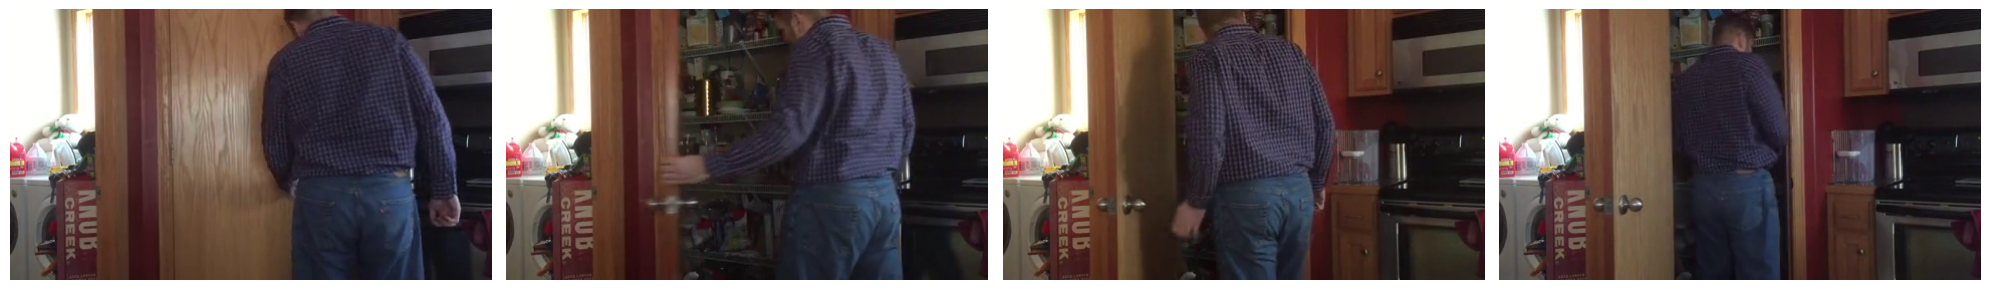

In [ ]:
video_path = RAW_VIDEO_DIR / f"{gt_df.loc[idx]['video_id']}.mp4"
start = gt_df.loc[idx]['start']
end = gt_df.loc[idx]['end']
# values used in the experiments
fps = 1
max_frames = 64

frame_dir, frame_paths = video_tools.extract_frames(
    video_path,
    fps=fps,
    max_frames=max_frames,
    start_time=start,
    end_time=end,
)

images = frame_paths
fig, axes = plt.subplots(1,  len(images), figsize=(20, 12))

for ax, img_path in zip(axes, images):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()


#### Inspect the video

In [ ]:
SHOW_VIDEO = True
if SHOW_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


	Video Seg:  0.0s - 4.4s


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [159]:
if SHOW_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


In [160]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][0]['content'])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- sitting_on ---- sofa
laptop ---- on_lap_of ---- person
person ---- wearing ---- red_top
person ---- wearing ---- light_vest
person ---- wearing ---- dark_trousers
cushion_or_blanket ---- on_sofa_left_of ---- person
plaid_blanket ---- draped_over ---- sofa_back
floor ---- made_of ---- wood
lamp ---- on_right_side_of ---- frame
</scene_graph>

Frame 1:
<scene_graph>
person ---- sitting_on ---- sofa
laptop ---- on_lap_of ---- person
person ---- interacting_with ---- laptop
cushion_or_blanket ---- on_sofa_left_of ---- person
plaid_blanket ---- draped_over ---- sofa_back
floor ---- made_of ---- wood
lamp ---- on_right_side_of ---- frame
</scene_graph>

Frame 2:
<scene_graph>
person ---- closing ---- laptop
laptop ---- on_lap_of ---- person
person ---- seated_on ---- sofa
cushion_or_blanket ---- on_sofa_le